In [76]:
from jupyterlab_widgets import data
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from numpy import genfromtxt
import astropy.units as u
from astropy.constants import h, c, e
import math

hello = e
print(hello)
from astropy import constants as const

#h = 6.62606957 * 10 ** (-34)
c0 = 299792458
charge = 1.602176634e-19
thickness = 1 * 10 ** (-5)


def GaussAmp(x, y0, A, x0, fwhm):
    w = fwhm / np.sqrt(np.log(4))
    exponential = ((x - x0) ** 2) / (2 * (w ** 2))
    y = y0 + A * np.exp(-exponential)
    return y


#make a bunch of useful functions
def zero_remover(data):  #Only for lists
    zero_removed_data = []
    for i in range(0, len(data)):
        if data[i] > 0:
            zero_removed_data.append(data[i])
        else:
            zero_removed_data.append(0)
    zero_removed_data = np.array(zero_removed_data)
    return zero_removed_data


def csv_to_numpy(csv_file):
    all_data = genfromtxt(csv_file, delimiter=",", dtype=float, missing_values=["NaN", "#DIV/0!"], filling_values=0)
    all_data_removed_headers = all_data[2:, :]
    cleaned_data = np.where(all_data_removed_headers > 0, all_data_removed_headers, 0)
    return cleaned_data


def seperated_data(clean_data):
    wavelength = np.array(clean_data[:, 0]) * u.nm
    transmission0 = np.array(clean_data[:, 1])
    transmission100 = np.array(clean_data[:, 2])
    BA2PbI4 = np.array(clean_data[:, 3])
    #SC_BA2MAPb2I7 = np.array(clean_data[:, 4])
    #PC_BA2MAPb2I7 = np.array(clean_data[:, 5])

    #energy_J = h * c0 / (wavelength * (10 ** (-9)))
    #energy_eV = energy_J * u.J
    #energy_eV.to(u.eV)

    #wavelength = np.array(clean_data[:, 0]) * u.nm

    energy_eV = (h * c / wavelength).to(u.eV).value

    incident = transmission100 - transmission0
    BA2PbI4_background = BA2PbI4 - transmission0
    #SC_BA2MAPb2I7_background = SC_BA2MAPb2I7 - transmission0
    #PC_BA2MAPb2I7_background = PC_BA2MAPb2I7 - transmission0
    return energy_eV, wavelength, incident, BA2PbI4_background#, SC_BA2MAPb2I7_background, PC_BA2MAPb2I7_background


def all_calcs(incident, material):
    tranmission_material = (material / incident) * 100  #is this absorpTance & visa versa?
    # Absorbance, safely handling divide-by-zero
    with np.errstate(divide='ignore', invalid='ignore'):
        absorbance = np.log10(incident / material)
        absorbance[~np.isfinite(absorbance)] = 0  # set inf/nan to 0
    coefficient_literature = (np.log(10) / thickness) * absorbance
    return tranmission_material, absorbance, coefficient_literature


def transmissionPlot(wavelength, incident, Material_background, colour_index, key, key_index):
    tranmission_material, absorbance, coefficient_literature = all_calcs(incident, Material_background)

    index_add_value = key_index
    indexed_transmission_material = index_add_value + tranmission_material
    cmap = plt.cm.viridis
    colour = cmap(colour_index)
    plt.plot(wavelength, indexed_transmission_material, label=f"{key}h", color=colour, linewidth=2)
    return


def absorbancePlot(wavelength, incident, Material_background, colour_index, key, key_index):
    tranmission_material, absorbance, coefficient_literature = all_calcs(incident, Material_background)

    index_add_value = key_index
    indexed_transmission_material = index_add_value + absorbance
    cmap = plt.cm.viridis  #cmc.batlow.resampled(25)
    colour = cmap(colour_index)
    plt.plot(wavelength, indexed_transmission_material, label=f"{key}h", color=colour, linewidth=2)
    return


def AbsCoPlot(wavelength, incident, Material_background, colour_index, key, key_index):
    tranmission_material, absorbance, coefficient_literature = all_calcs(incident, Material_background)

    index_add_value = key_index
    indexed_transmission_material = index_add_value + coefficient_literature
    cmap = plt.cm.viridis  #cmc.batlow.resampled(25)
    colour = cmap(colour_index)
    plt.plot(wavelength, indexed_transmission_material, label=f"{key}h", color=colour, linewidth=2)
    return


def format_sig_fig(x, sig_fig):
    """
    Format a number x to sig_fig significant figures,
    preserving trailing zeros as decimal places when needed.
    """
    if x == 0:
        return f"{0:.{sig_fig}f}"  # just return 0.00... for consistency
    # Determine how many digits before decimal
    import math
    digits_before_decimal = int(math.floor(math.log10(abs(x)))) + 1
    decimals_needed = max(sig_fig - digits_before_decimal, 0)
    return f"{x:.{decimals_needed}f}"

  Name   = Electron charge
  Value  = 1.602176634e-19
  Uncertainty  = 0.0
  Unit  = C
  Reference = CODATA 2018


In [77]:
##Load in the data
directory = r"A:\Y4 Project code\Data\Raw data sample 6"
# Use glob to find all CSV files (recursively if needed)
csv_files = glob.glob(os.path.join(directory, "*.csv"))

data_dict = {}

for file in csv_files:
    key = os.path.splitext(os.path.basename(file))[0]
    #print(key)
    key = key.replace("Heat and cool - ", "", 1) #format == key.replace("old bit of key", "new bit of key", "counts(if counts == 1 then replaces all instances)")
    #print(key)

    #print(key)
    #short_key = key.split(" - ")[0].strip()
    #short_key = short_key.split(" -")[0].strip()
    #short_key = short_key.split("-")[0].strip() # remove everything after the "-" in the item called "short_key"

    #short_key = short_key.replace("m", "",1)
    #short_key = short_key.replace(" heat", "",1)


    #hours = int(short_key.split("h")[0].strip())
    #print(hours, "hours")
    #minutes = int(short_key.split("h")[1].strip()) if len(short_key) > 1 and short_key.split("h")[1].strip() else 0
    #print(minutes, "minutes")
    #if minutes > 30:
    #    hours = hours + 1

    #print(short_key)
    #print(key)
    data_dict[key] = csv_to_numpy(file)
#print(data_dict.keys())
#print(data_dict["0"][:, 0])
#print(data_dict["0"][:, 1])
#print(data_dict["0"][:, 2])
#print(data_dict["0"][:, 3])
#print(data_dict["0"][:, 4])
#print(data_dict["0"][:, 5])

#the order of the keys is in the awful ['0', '139', '162', '167', '185', '192', '1', '209', '21', '215', '26', '44', '50', '67', '73'] order. We need to fix that
#key_list = []
#for key in data_dict.keys():
#    key_list.append(int(key))
#    correct_key_order = np.argsort(key_list)
#print(correct_key_order)


#correct_keys = []

#for key in correct_key_order:
#    correct_keys.append(key_list[key])


#new_dict = {}

#for key in correct_keys:
#    new_dict[str(key)] = data_dict[str(key)]
#data_dict = new_dict
# print(data_dict.keys()) #viola!
def parse_key(key):
    temp = float(key.split('K')[0])
    material = key.split('-')[1].strip()
    return temp, material

# Separate groups
c_items = []
h_items = []

for k, v in data_dict.items():
    temp, material = parse_key(k)
    if material == 'C':
        c_items.append((k, v, temp))
    else:
        h_items.append((k, v, temp))

# Sort groups
c_items.sort(key=lambda x: x[2], reverse=True)  # descending temp
h_items.sort(key=lambda x: x[2])                 # ascending temp

# Rebuild dictionary
data_dictN1 = {k: v for k, v, _ in c_items + h_items}

print(data_dictN1.keys())

dict_keys(['290K - C', '273K - C', '250K - C', '200K - C', '175K - C', '150K - C', '125K - C', '100K - C', '75K - C', '50K - C', '25K - C', '5.7K - C', '25K - H', '50K - H', '75K - H', '100K - H', '125K - H', '150K - H', '175K - H', '200K - H', '225K - H', '250K - H', '275K - H', '300K - H'])


In [78]:
#Load in the data
directory = r"A:\Y4 Project code\Data\Raw data sample 5"
# Use glob to find all CSV files (recursively if needed)
csv_files = glob.glob(os.path.join(directory, "*.csv"))

data_dict = {}

for file in csv_files:
    key = os.path.splitext(os.path.basename(file))[0]
    #print(key)
    key = key.replace("SC N2 cryostat data - ", "", 1) #format == key.replace("old bit of key", "new bit of key", "counts(if counts == 1 then replaces all instances)")
    #print(key)

    #print(key)
    #short_key = key.split(" - ")[0].strip()
    #short_key = short_key.split(" -")[0].strip()
    #short_key = short_key.split("-")[0].strip() # remove everything after the "-" in the item called "short_key"

    #short_key = short_key.replace("m", "",1)
    #short_key = short_key.replace(" heat", "",1)


    #hours = int(short_key.split("h")[0].strip())
    #print(hours, "hours")
    #minutes = int(short_key.split("h")[1].strip()) if len(short_key) > 1 and short_key.split("h")[1].strip() else 0
    #print(minutes, "minutes")
    #if minutes > 30:
    #    hours = hours + 1

    #print(short_key)
    #print(key)
    data_dict[key] = csv_to_numpy(file)
#print(data_dict.keys())
#print(data_dict["0"][:, 0])
#print(data_dict["0"][:, 1])
#print(data_dict["0"][:, 2])
#print(data_dict["0"][:, 3])
#print(data_dict["0"][:, 4])
#print(data_dict["0"][:, 5])

#the order of the keys is in the awful ['0', '139', '162', '167', '185', '192', '1', '209', '21', '215', '26', '44', '50', '67', '73'] order. We need to fix that
#key_list = []
#for key in data_dict.keys():
#    key_list.append(int(key))
#    correct_key_order = np.argsort(key_list)
#print(correct_key_order)
correct_key_order = [18, 16, 13, 11, 9, 7, 4, 2, 0, 23, 20, 6, 22, 15, 21, 24, 1, 3, 5, 8, 10, 12, 14, 17, 19]

#correct_keys = []
def parse_key(key):
    temp = float(key.split('K')[0])
    material = key.split('-')[1].strip()
    return temp, material

# Separate groups
c_items = []
h_items = []

for k, v in data_dict.items():
    temp, material = parse_key(k)
    if material == 'C':
        c_items.append((k, v, temp))
    else:
        h_items.append((k, v, temp))

# Sort groups
c_items.sort(key=lambda x: x[2], reverse=True)  # descending temp
h_items.sort(key=lambda x: x[2])                 # ascending temp

# Rebuild dictionary
data_dictSC = {k: v for k, v, _ in c_items + h_items}

print(data_dictSC.keys())

dict_keys(['293K - C', '275K - C', '250K - C', '225K - C', '200K - C', '175K - C', '150K - C', '125K - C', '100K - C', '75K - C', '50K - C', '16K - C', '6K - C', '25K - H', '50K - H', '75K - H', '100K - H', '125K - H', '150K - H', '175K - H', '200K - H', '225K - H', '250K - H', '275K - H', '300K - H'])


In [79]:
data_dictPC = []

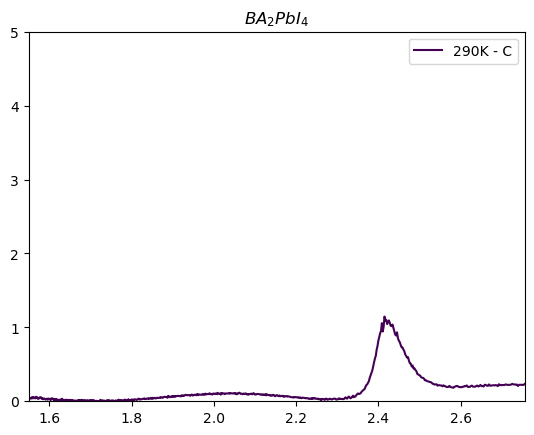

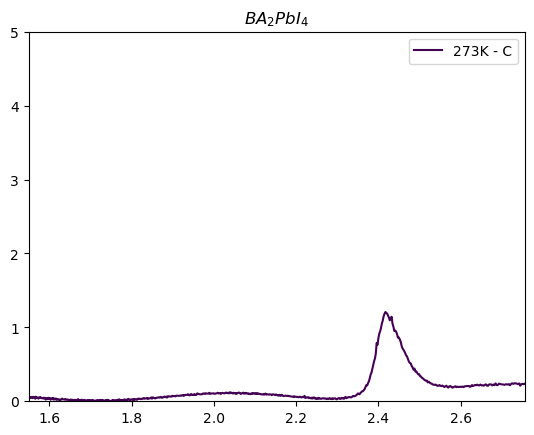

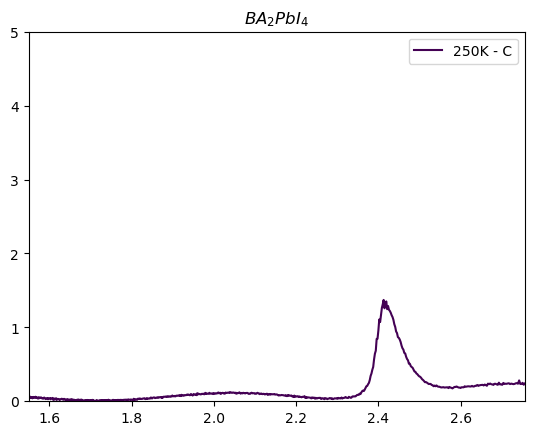

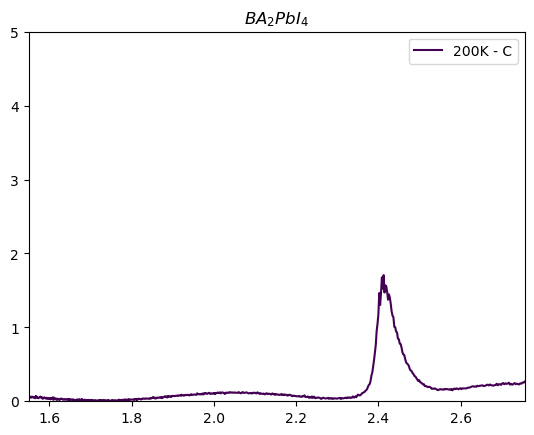

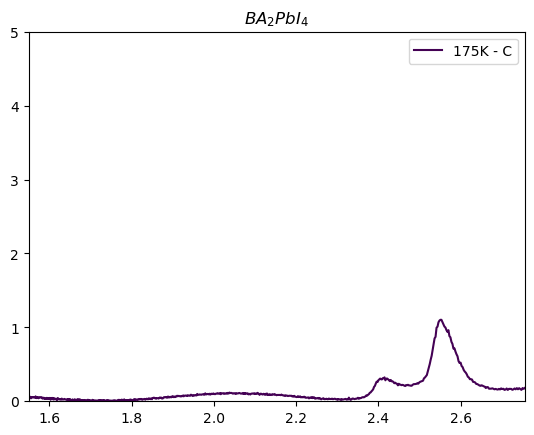

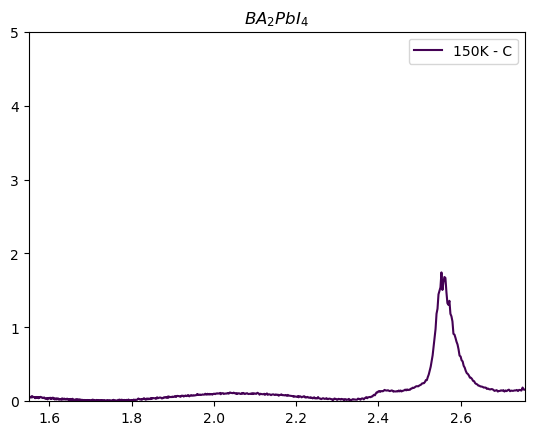

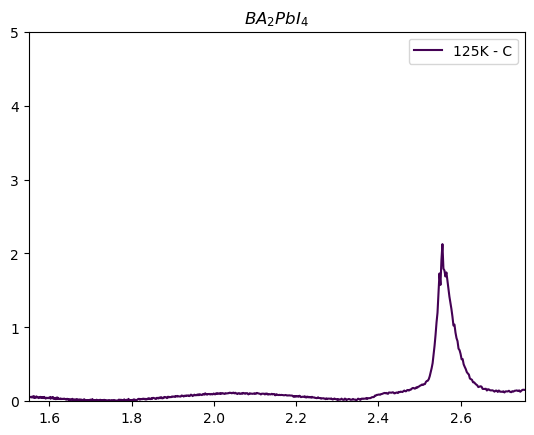

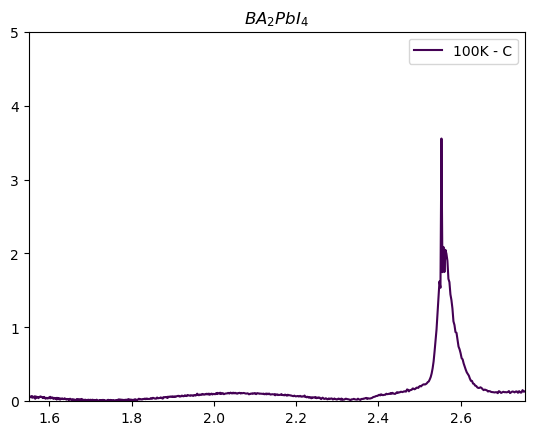

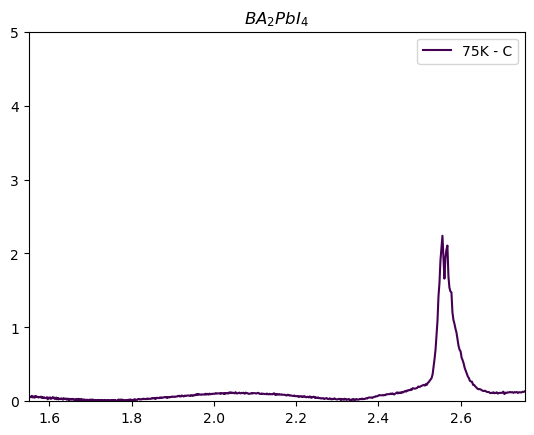

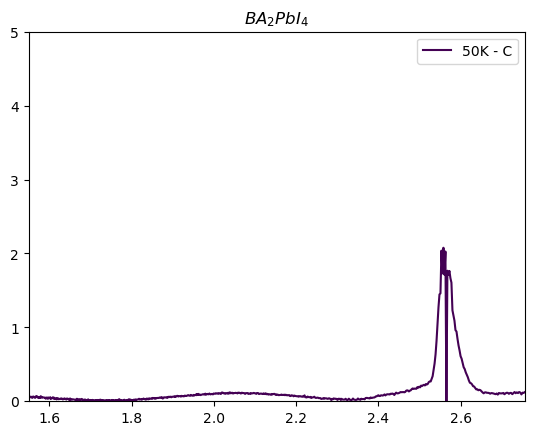

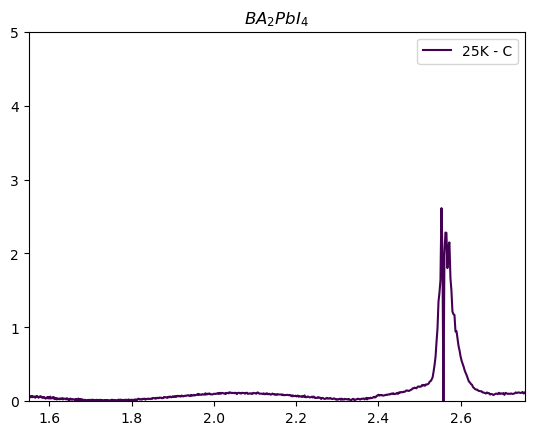

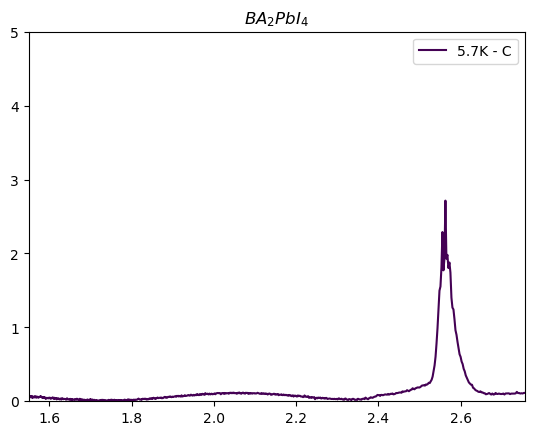

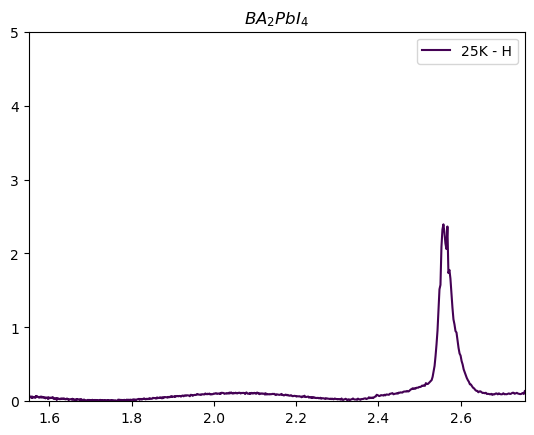

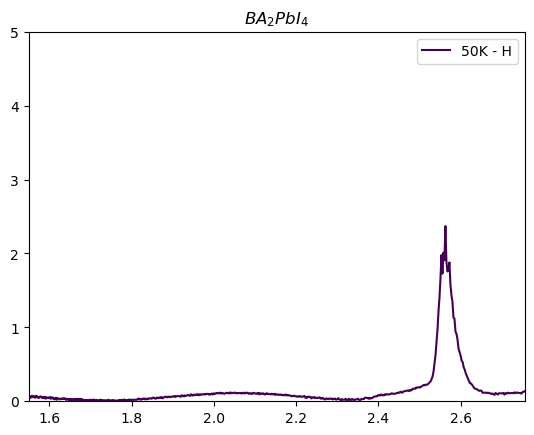

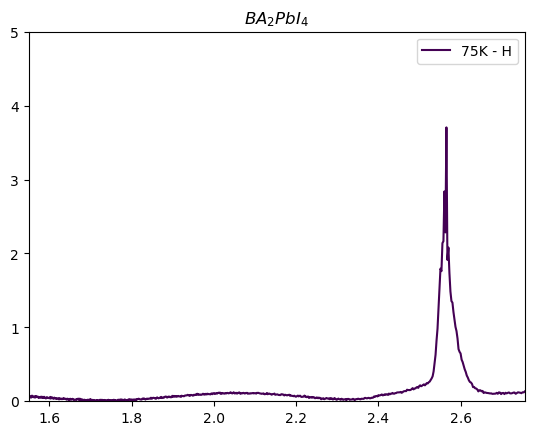

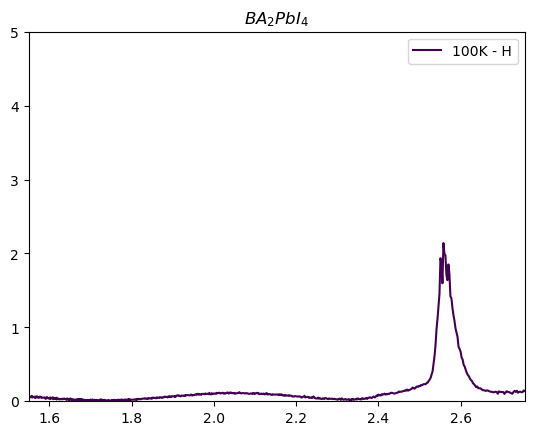

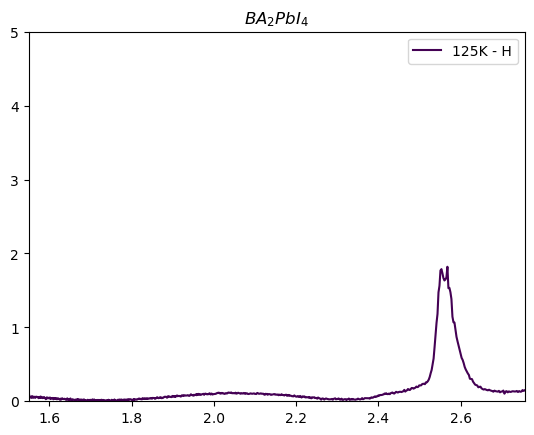

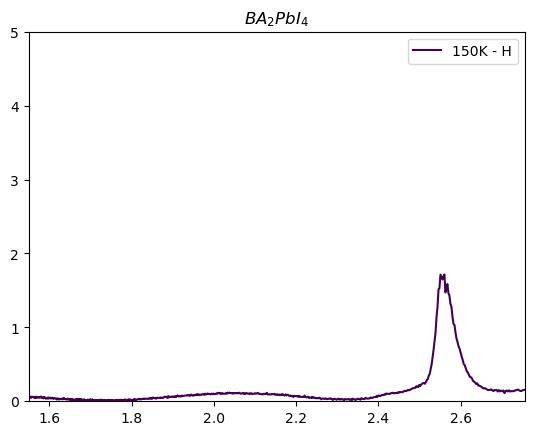

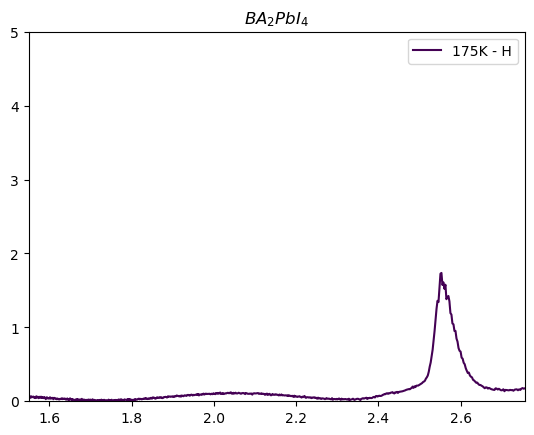

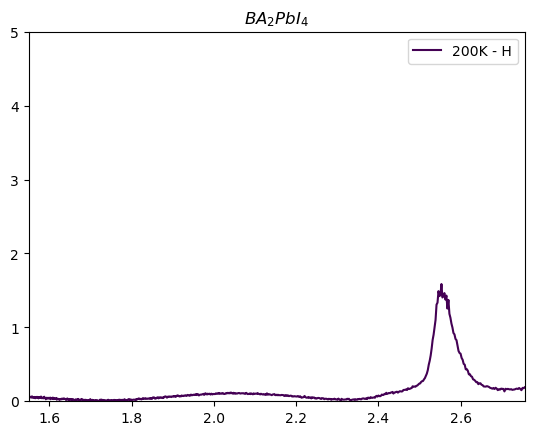

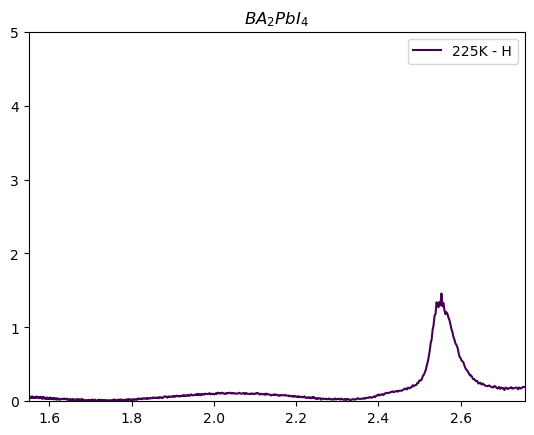

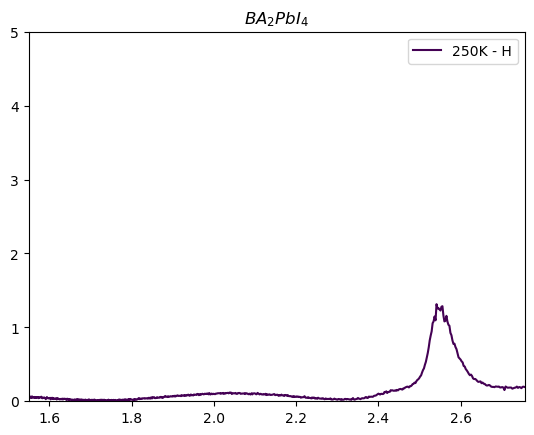

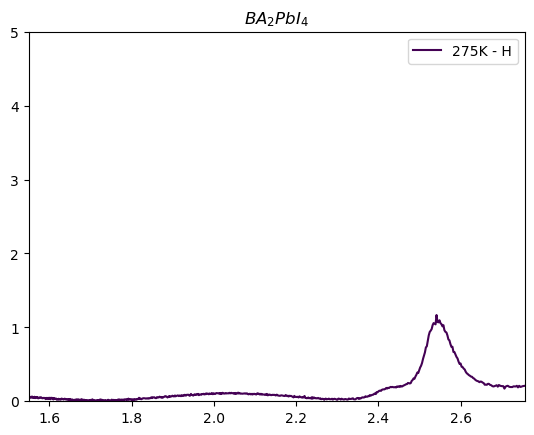

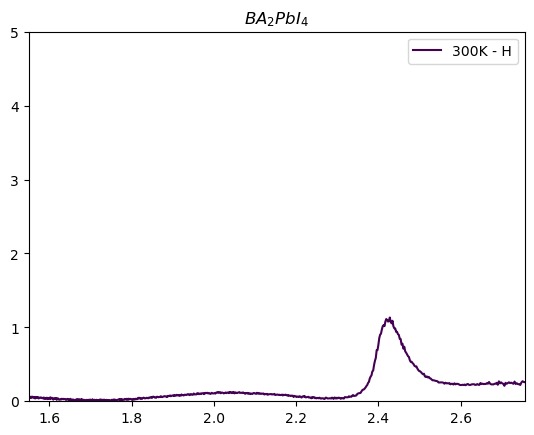

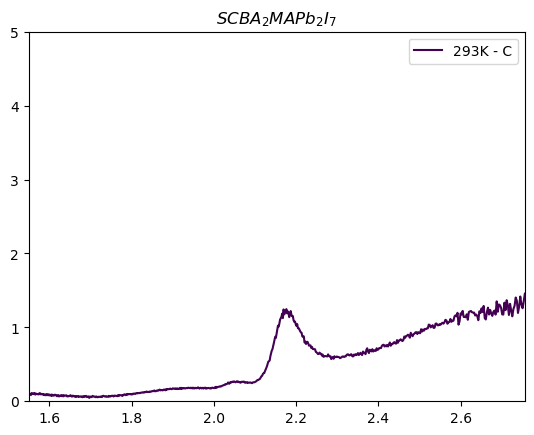

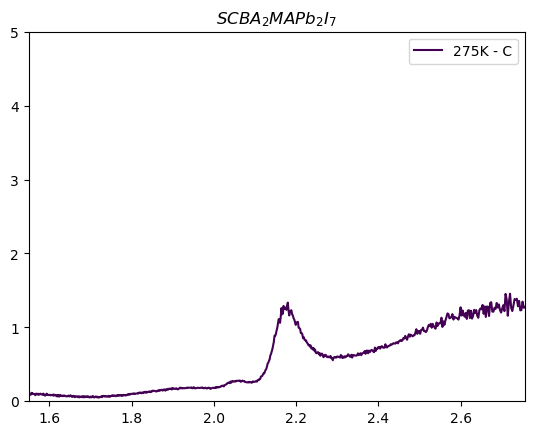

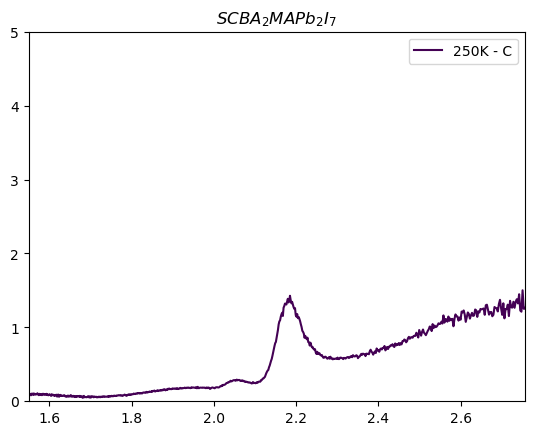

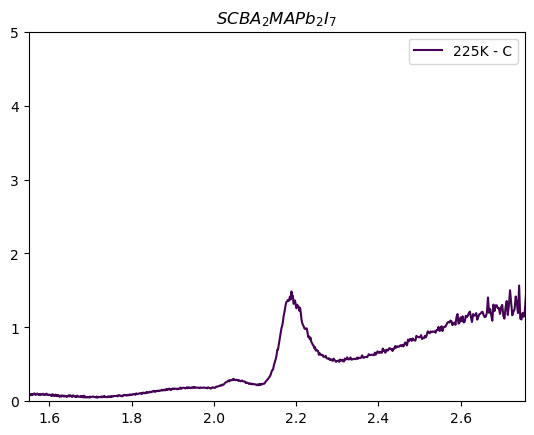

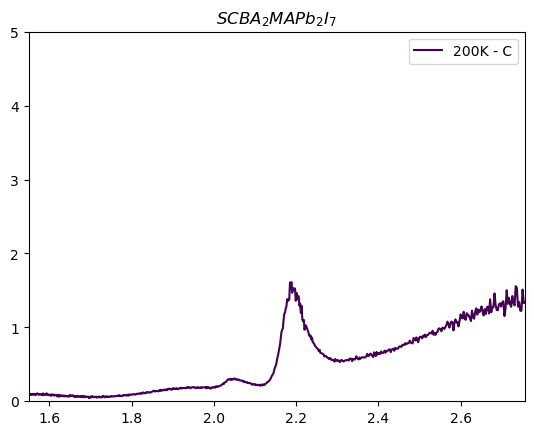

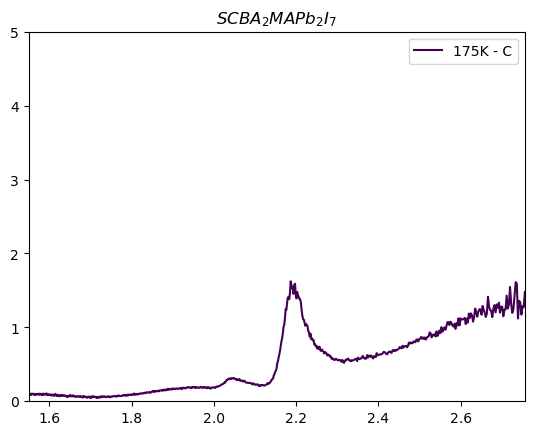

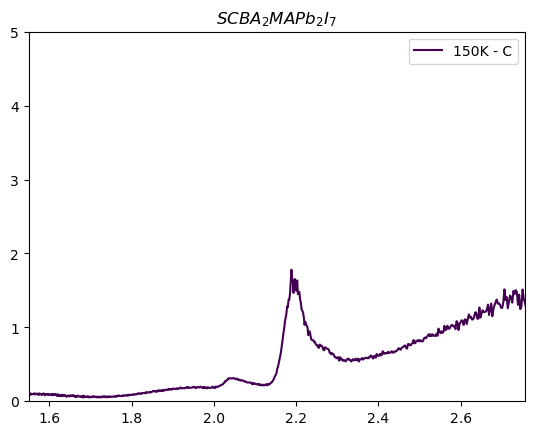

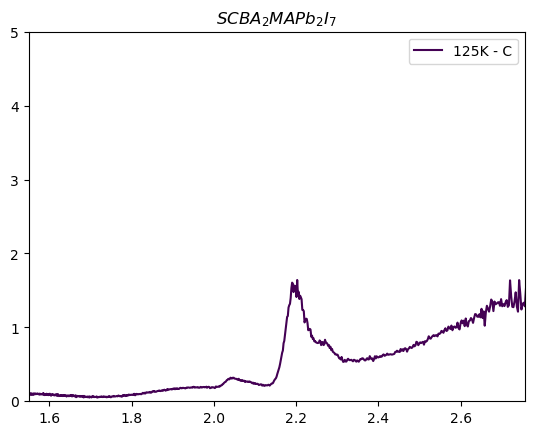

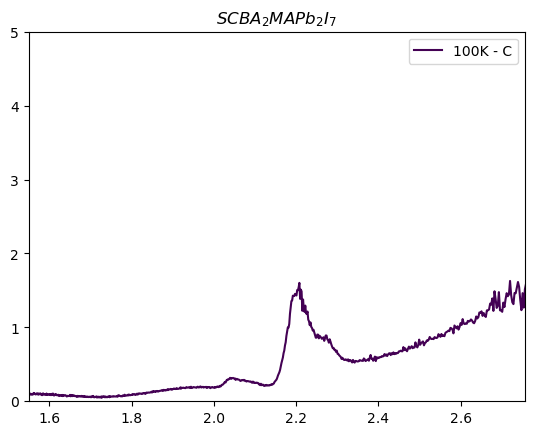

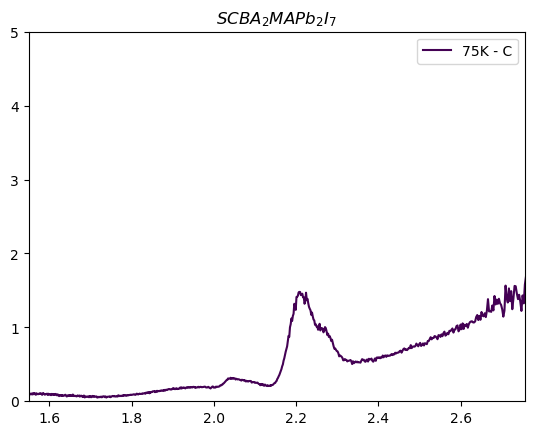

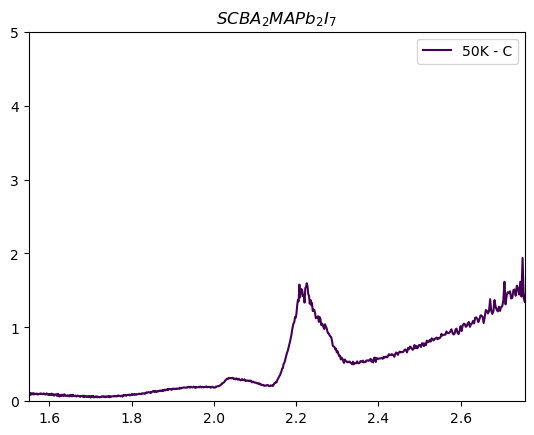

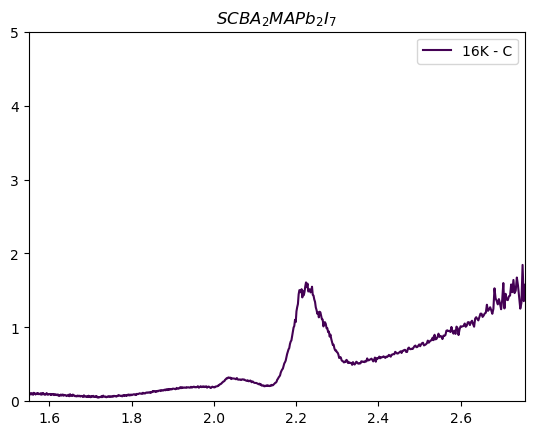

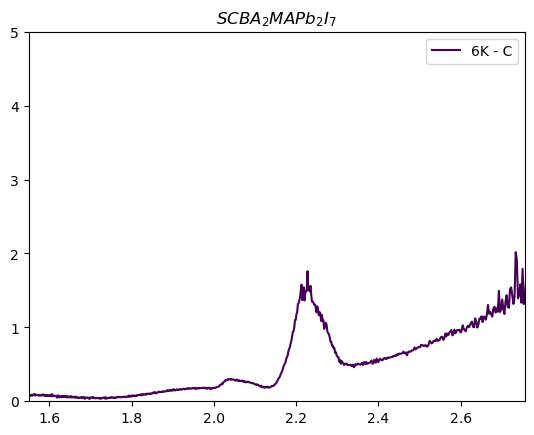

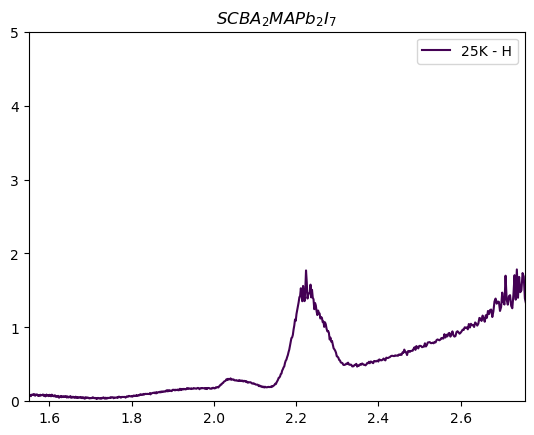

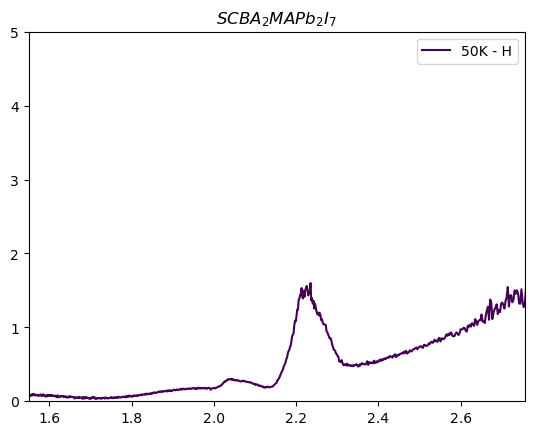

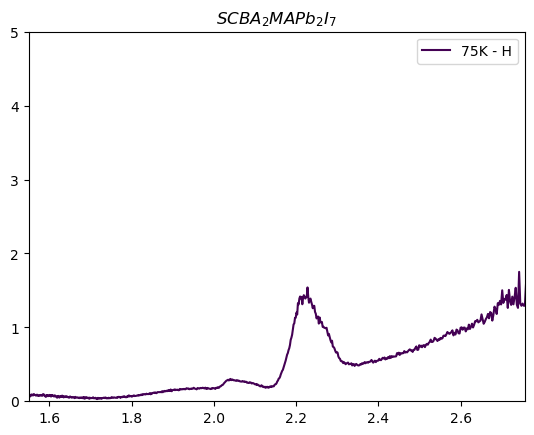

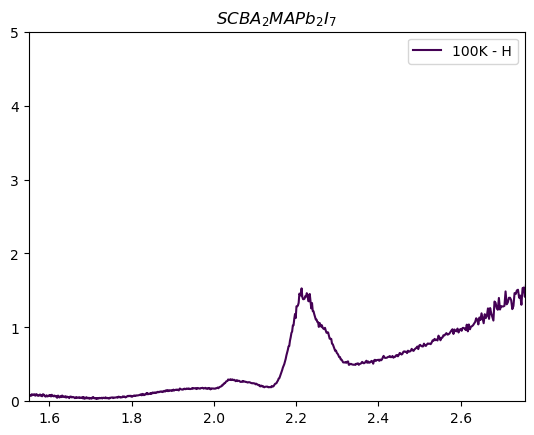

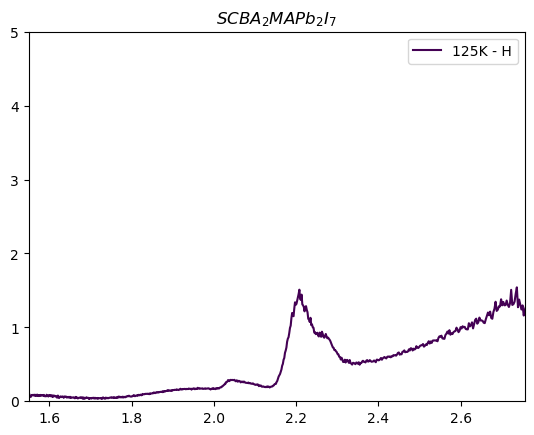

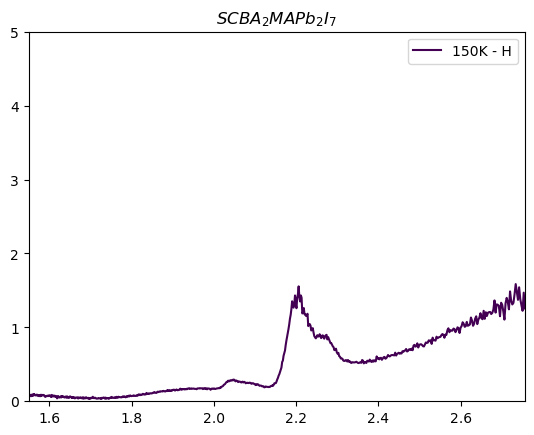

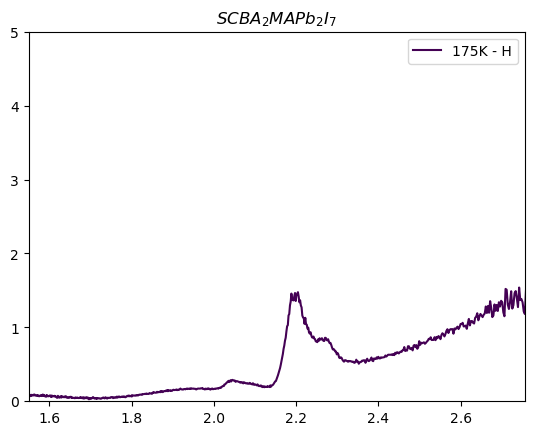

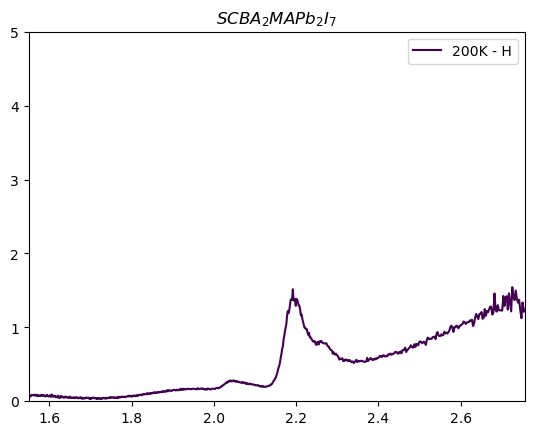

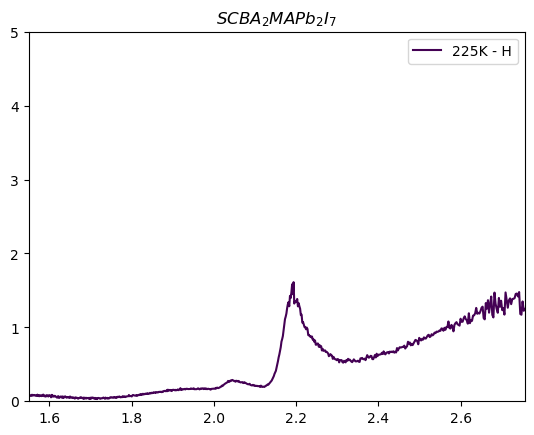

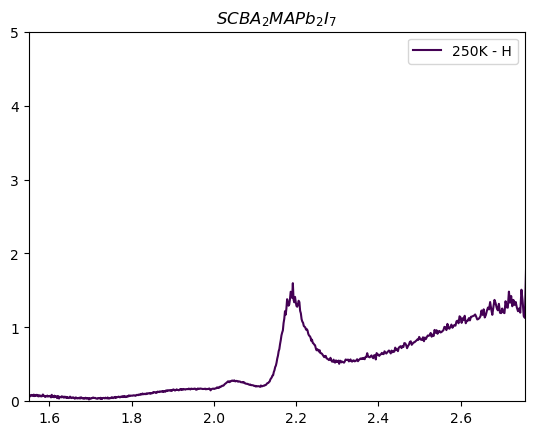

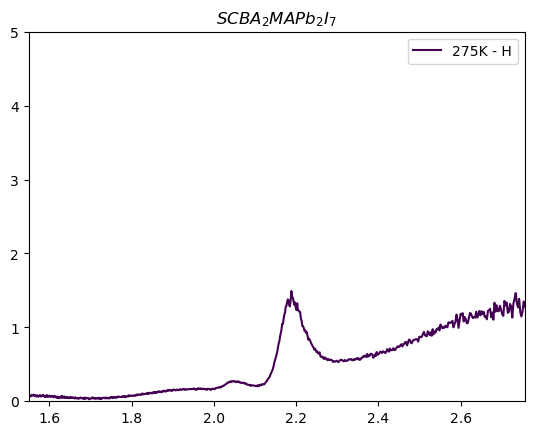

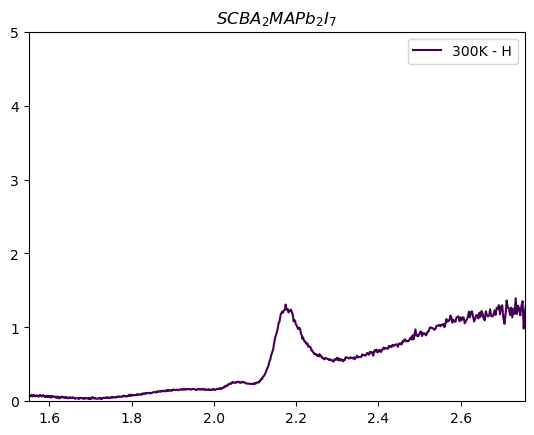

In [80]:
#plot the data for BA2PbI4, SC BA2MAPb2I7 & PC BA2MAPb2I7
nth_plot = 0
materials = [data_dictN1, data_dictSC, data_dictPC]

for material in materials:
    if material == data_dictN1:
        title = r"$BA_{2}PbI_{4}$"
    elif material == data_dictSC:
        title = r"$SC BA_{2}MAPb_{2}I_{7}$"
    elif material == data_dictPC:
        title = r"$PC BA_{2}MAPb_{2}I_{7}$"
    else:
        print("Error, Error, Error")
    data_dict=material
    for key_index, key in enumerate(data_dict):
        energy_eV, wavelength, incident, BA2PbI4_background = seperated_data(data_dict[key])
        absorbance = []

        for i in range(len(energy_eV)):
            if BA2PbI4_background[i] == 0:
                ratio = 1
            else:
                ratio = incident[i] / BA2PbI4_background[i]

            if ratio <= 0:
                ratio = 1e-12   # avoid log(0) or negative

            absorbance.append(np.log10(ratio))
        colour_index = (nth_plot) / (len(data_dict)) #* 0.8
        nth_plot += 1
        cmap = plt.cm.viridis
        colour = cmap(colour_index)
        plt.plot(energy_eV, absorbance, color=colour, label=key)
        plt.legend()

        plt.xlim(
        (h*c0/(charge * 800e-9)).value,
        (h*c0/(charge * 450e-9)).value
        )
        plt.ylim(0, 5)
        plt.title(title)
        plt.show()
        nth_plot = 0